In [123]:
""" Imports """
%load_ext autoreload
%autoreload 2
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
""" Image functions """
def plot_image_grid(images_data, fig, axes):
    for item in images_data:
        row = item['row']
        col = item['col']
        image = item['image']
        title = item.get('title', '')
        cmap = item.get('cmap', 'gray')
        
        if axes.ndim == 1:
            ax = axes[col]
        else:
            ax = axes[row, col]

        if title:
            ax.set_title(title, pad=0, fontsize=14)
            
        if isinstance(image, torch.Tensor):
            image = image.detach().cpu().numpy()
            
        ax.imshow(image, cmap=cmap)
        ax.axis('off')

def get_original_images(samples, labels, channels, start_row, title="Original Timepoint"):
    images_data = []
    for j, sample in enumerate(samples):
        images = sample.squeeze()
        
        if images.ndim == 2:
            images_data.append({
                'image': images,
                'title': f"{title} {labels[j]}",
                'row': start_row,
                'col': j
            })
        elif images.ndim == 3:
            for i, image in enumerate(images):
                title = f"{title} {labels[j]}" if i == 0 else ""
                images_data.append({
                    'image': image,
                    'title': title,
                    'row': start_row + i,
                    'col': j
                })
        else:
            raise ValueError("Unsupported image dimensions. Expected 2D or 3D images.")
            
    return images_data

def get_reconstructed_images(samples, model, channels, start_row, title="Predicted Timepoint"):
    images_data = []
    for j, sample in enumerate(samples):
        model.eval()
        sample_input = sample.unsqueeze(0)
        
        with torch.no_grad():
            result = model(sample_input)
            
        reconstructed_image, label_pred = result[:2]
        reconstructed_image = reconstructed_image.squeeze()
        label_pred = torch.max(label_pred, dim=1)[1].item()
        
        if reconstructed_image.ndim == 2:
            images_data.append({
                'image': reconstructed_image,
                'title': f"{title}",
                'row': start_row,
                'col': j
            })
        elif reconstructed_image.ndim == 3:
            for i, image in enumerate(reconstructed_image):
                title = f"{title} {label_pred}" if i == 0 else ""
                images_data.append({
                    'image': image,
                    'title': title,
                    'row': start_row + i,
                    'col': j
                })
        else:
            raise ValueError("Unsupported image dimensions. Expected 2D or 3D images.")
            
    return images_data

def get_difference_images(samples, model, channels, start_row, cmap="bwr"):
    imgs = []
    for j, sample in enumerate(samples):
        with torch.no_grad():
            recon, _ = model(sample.unsqueeze(0))[:2]
        recon, orig = recon.squeeze(), sample.squeeze()

        diffs = recon - orig
        if diffs.ndim == 2:
            diffs = diffs.unsqueeze(0)

        for ch_idx, diff in enumerate(diffs):
            m = diff.abs().max().item() or 1.0
            imgs.append(
                {
                    "image": diff,
                    "title": "",
                    "row": start_row + ch_idx,
                    "col": j,
                    "cmap": cmap,
                    "vmin": -m,
                    "vmax": m,
                }
            )
    return imgs

def get_saliency_maps(dataset, indices, model, start_row, title="Saliency Map"):
    images_data = []
    for j, idx in enumerate(indices):
        data = dataset[idx]
        input_tensor = data[0].unsqueeze(0)
        
        # Generate saliency map
        saliency_map = model.get_saliency_map(input_tensor).squeeze()
        
        images_data.append({
            'image': saliency_map,
            'title': f"{title}",
            'row': start_row,
            'col': j,
            'cmap': 'hot'
        })
        
    return images_data

""" Plotting functions """
def extract_seeds(all_loaders, loader_type):
    return {
        experiment: {
            dataset_name: [key.split('_')[-1] for key in datasets["full"].get_seed_keys(loader_type)]
            for dataset_name, datasets in models.items()
        }
        for experiment, models in all_loaders.items()
    }

def process_colors(experiment, dataset_name, seeds, timepoints):
    color_seeds = [int(seed) for seed in seeds[experiment][dataset_name]]
    color_timepoints = [int(timepoint) for timepoint in timepoints[experiment][dataset_name]]
    color_seeds_unique = list(set(color_seeds))
    return color_seeds, color_timepoints, color_seeds_unique

def plot_time_ordered_points(ax, embeddings, color_seeds, color_timepoints, title, xlabel, ylabel):
    selected_points = [(x, y) for k, (x, y) in enumerate(embeddings) if color_seeds[k] in color_seeds_unique]
    selected_timepoints = [color_timepoints[k] for k in range(len(color_seeds)) if color_seeds[k] in color_seeds_unique]

    if len(selected_points) > 1:
        # Ensure points are ordered by time
        sorted_indices = sorted(range(len(selected_timepoints)), key=lambda k: selected_timepoints[k])
        ordered_points = [selected_points[i] for i in sorted_indices]
        ordered_timepoints = [selected_timepoints[i] for i in sorted_indices]

        # Create line segments between consecutive points
        segments = [
            (ordered_points[i], ordered_points[i + 1]) for i in range(len(ordered_points) - 1)
        ]
        segment_colors = ordered_timepoints[:-1]
        norm = plt.Normalize(min(segment_colors), max(segment_colors))
        lc = LineCollection(segments, cmap='viridis', norm=norm)
        lc.set_array(segment_colors)
        lc.set_linewidth(2)

        ax.add_collection(lc)
        ax.scatter(*zip(*ordered_points), c=ordered_timepoints, cmap='viridis', s=50)  # Optional to highlight points

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(lc, ax=ax, label='Timepoints')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Data Loading

In [125]:
study_name = "cae-architecture-ARCADE"
image_dir = "data"
num_timepoints = 15

results_dir = f"results/{study_name}"

all_models = load_models(results_dir, num_timepoints=num_timepoints, best_models_flag=True)
all_loaders = load_loaders(results_dir, image_dir)

print(f"Models: {list(all_models.keys())}")
print(f"Datasets: {list(all_loaders.keys())}")

all_samples = {}
all_labels = {}
data_loaders = {}
random_indices = {}

for dataset_name, loader in all_loaders.items():
    data_loaders[dataset_name] = {
        "train": loader.get_dataloader('train'),
        "test": loader.get_dataloader('test'),
        "full": loader,
    }
    
    loader_test_len = len(data_loaders[dataset_name]["test"].dataset)
    
    if dataset_name not in random_indices:
        random_indices[dataset_name] = np.random.choice(loader_test_len, 5, replace=False)
    
    indices = random_indices[dataset_name]
    all_samples[dataset_name] = []
    all_labels[dataset_name] = []
    
    for idx in indices:
        sample, label = data_loaders[dataset_name]["test"].dataset[idx]
        # print(loader._test_indices[idx])
        # og_idx = loader._test_indices[idx]
        # print(loader._get_data_feature(og_idx, "cancer"))
        all_labels[dataset_name].append(label)
        all_samples[dataset_name].append(sample)

Loading model cae_medium (8.70e+06 parameters)
Loading model cae_small (3.38e+07 parameters)
Models: ['cae-medium', 'cae-small']
Datasets: ['vascular_function_128']


## Image reconstruction

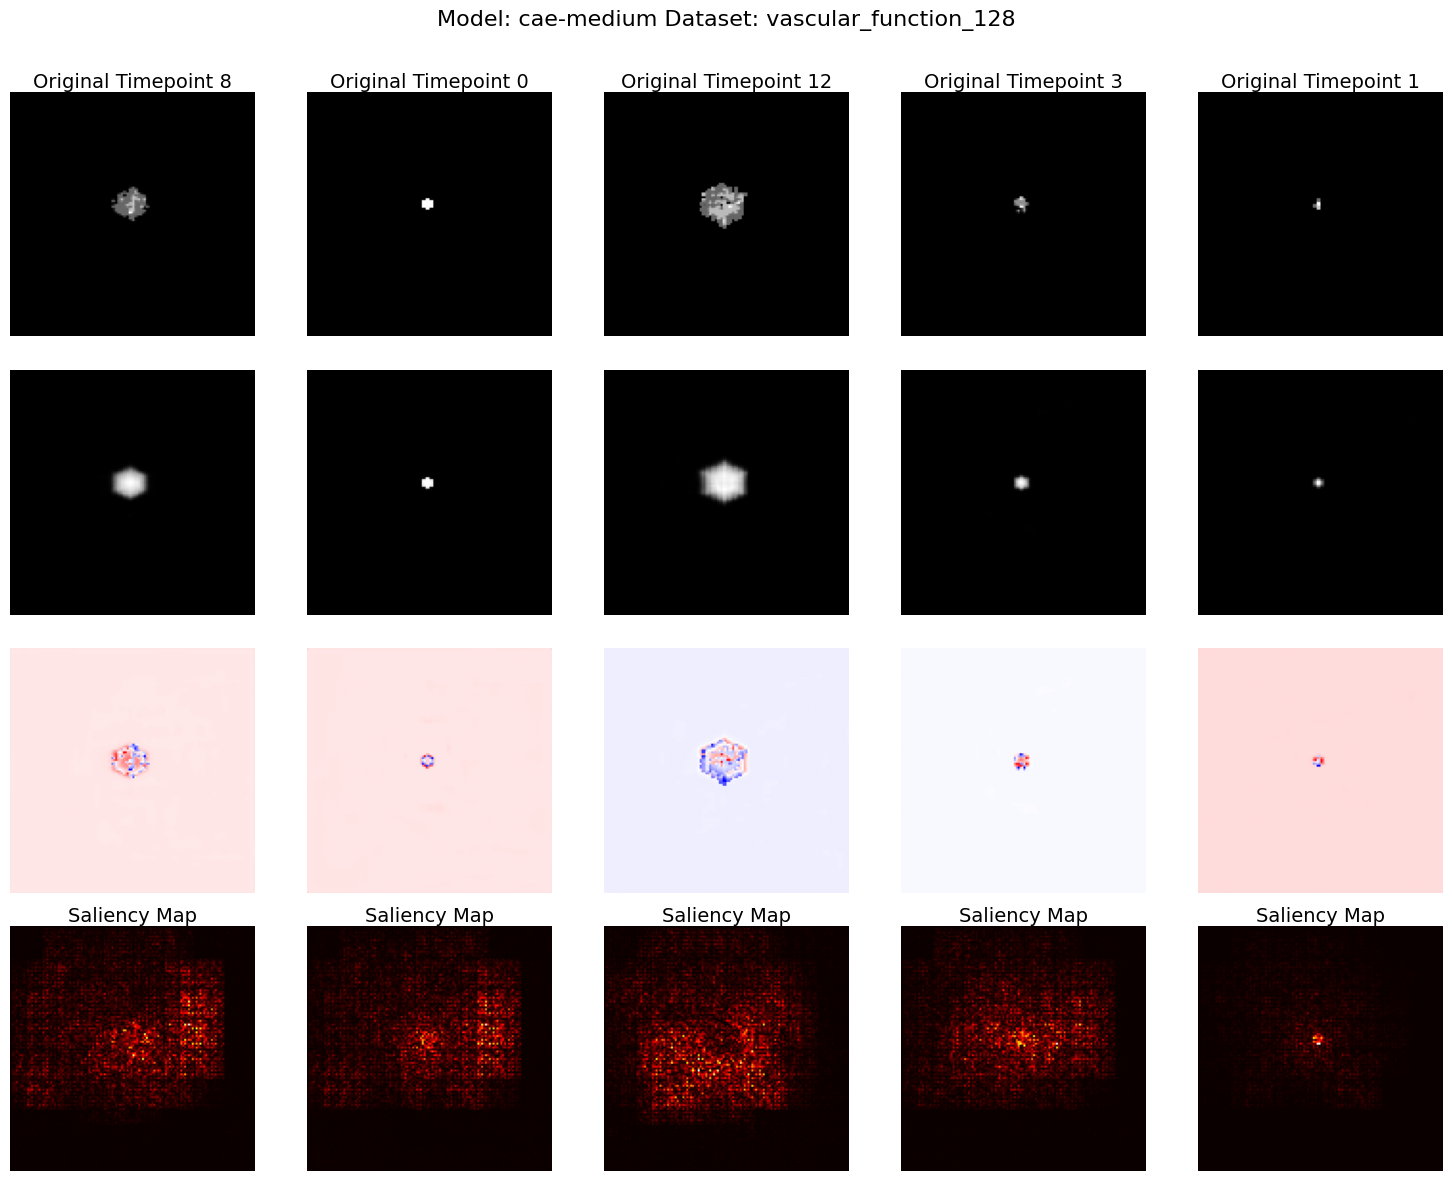

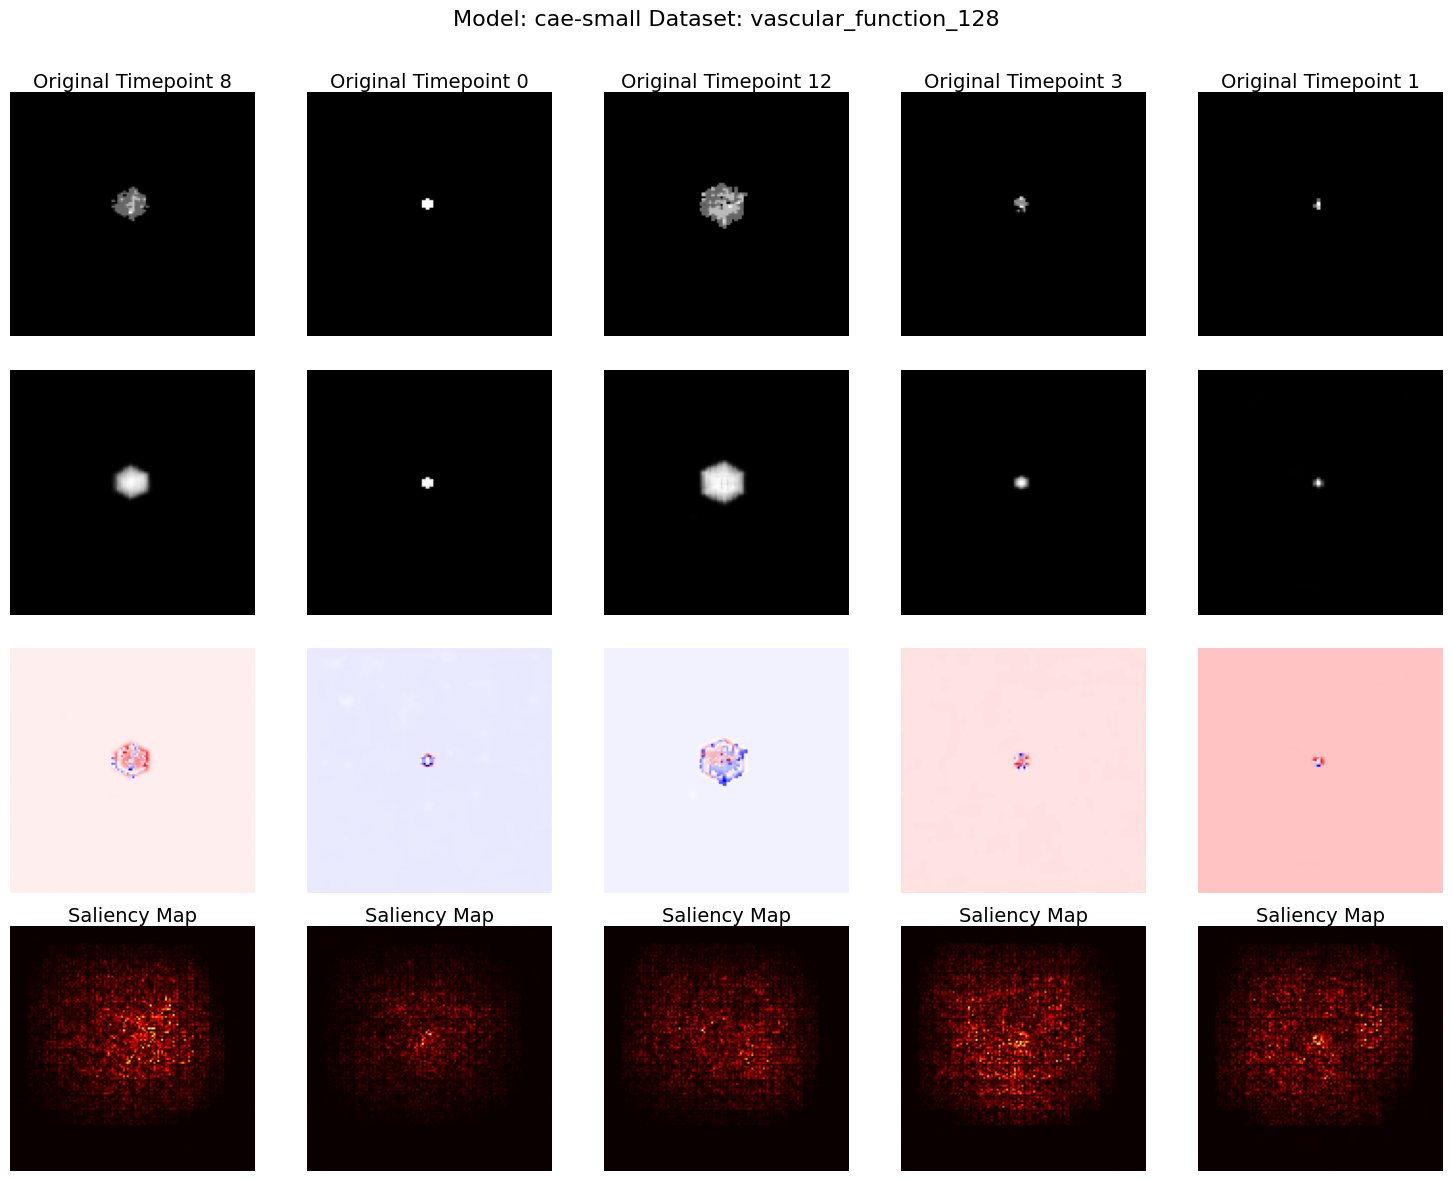

In [126]:
for model_name, dataset in all_models.items():
    for dataset_name, model in dataset.items():
        samples = all_samples[dataset_name]
        labels = all_labels[dataset_name]
        test_dataset = data_loaders[dataset_name]["test"].dataset
        channels = data_loaders[dataset_name]["full"].channels
        indices = random_indices[dataset_name]
        
        num_channels = len(channels)
        nrows = num_channels * 3 + 1  
        fig, axes = plt.subplots(nrows=nrows, ncols=5, figsize=(15, 12))
        
        all_images_data = []
        
        original_images = get_original_images(samples, labels, channels, start_row=0)
        all_images_data.extend(original_images)
    
        recon_start_row = num_channels
        reconstructed_images = get_reconstructed_images(samples, model, channels, start_row=recon_start_row, title="")
        all_images_data.extend(reconstructed_images)
        
        diff_start_row = num_channels * 2
        difference_images = get_difference_images(
            samples, model, channels, start_row=diff_start_row
        )
        all_images_data.extend(difference_images)

        saliency_start_row = num_channels * 3
        saliency_maps = get_saliency_maps(
            test_dataset, indices, model, start_row=saliency_start_row
        )
        all_images_data.extend(saliency_maps)

        for i in range(len(indices)):
            plt.imsave(f"figures/ARCADE/ARCADE_original_{model_name}_{i}.png", all_images_data[i]['image'], cmap='gray')
            plt.imsave(f"figures/ARCADE/ARCADE_reconstructed_{model_name}_{i}.png", all_images_data[i + 5]['image'], cmap='gray')
            plt.imsave(f"figures/ARCADE/ARCADE_difference_{model_name}_{i}.png", all_images_data[i + 10]['image'], cmap='bwr')
            
        plot_image_grid(all_images_data, fig, axes)
        fig.suptitle(f"Model: {model_name} Dataset: {dataset_name}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

In [127]:
random_images = {}
random_reconstructed_images = {}
processed_datasets = {}

for model_name, datasets in all_models.items():
    random_reconstructed_images[model_name] = {}
    for dataset_name, model in datasets.items():
        if dataset_name in processed_datasets:
            random_images[dataset_name] = processed_datasets[dataset_name]['random_images']
            random_reconstructed_images[dataset_name] = processed_datasets[dataset_name]['random_reconstructed_images']
        else:
            train_loader = data_loaders[dataset_name]["train"]
            test_loader = data_loaders[dataset_name]["test"]
            encoder = model.encoder
            last_layer = encoder[-1]
            dim = last_layer.out_features
            
            train_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in train_loader
            ]

            test_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in test_loader
            ]
            
            pca = PCA(n_components=dim)
            train_images_pca = pca.fit_transform(train_images)
            test_images_pca = pca.transform(test_images)
            reconstructed_test_images = pca.inverse_transform(test_images_pca)

            indices = random_indices[dataset_name]
            random_images_list = [test_images[i] for i in indices]
            random_reconstructed_images_list = [reconstructed_test_images[i] for i in indices]

            processed_datasets[dataset_name] = {
                'random_images': random_images_list,
                'random_reconstructed_images': random_reconstructed_images_list,
            }
            
            random_images[dataset_name] = random_images_list
            random_reconstructed_images[dataset_name] = random_reconstructed_images_list

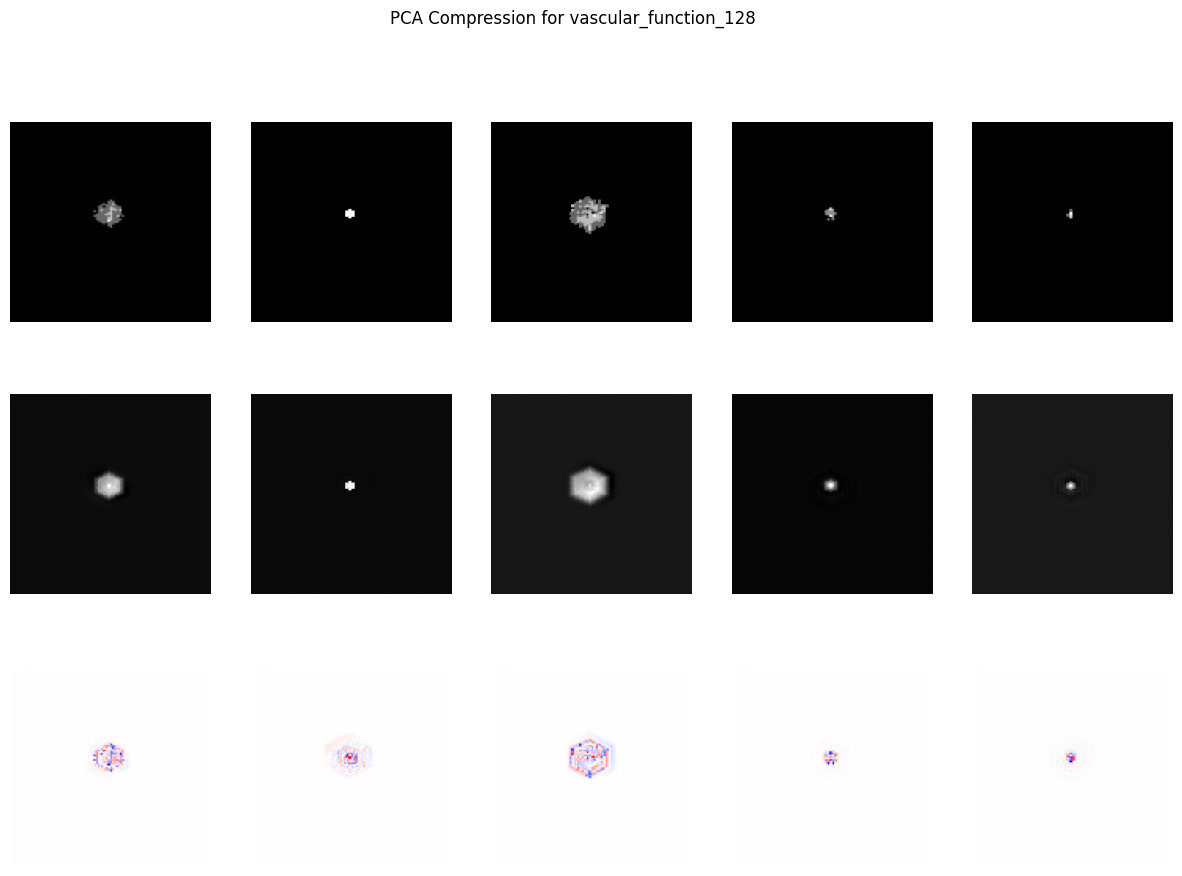

In [128]:
for dataset, _ in processed_datasets.items():
    reshaped_random_images = [
        img.reshape(num_channels, 128, 128) for img in random_images[dataset]
    ]
    reshaped_random_reconstructed_images = [
        img.reshape(num_channels, 128, 128) for img in random_reconstructed_images[dataset]
    ]

    nrows = num_channels * 3
    fig, axes = plt.subplots(nrows=nrows, ncols=5, figsize=(15, 10))
    
    for j, sample in enumerate(reshaped_random_images):
        for i, image in enumerate(sample):
            axes[i, j].imshow(image, cmap='gray')
            axes[i, j].axis('off')

    for j, sample in enumerate(reshaped_random_reconstructed_images):
        for i, image in enumerate(sample):
            axes[num_channels + i, j].imshow(image, cmap='gray')
            axes[num_channels + i, j].axis('off')

    for j, (orig_sample, recon_sample) in enumerate(
        zip(reshaped_random_images, reshaped_random_reconstructed_images)):
        for i, (orig, recon) in enumerate(zip(orig_sample, recon_sample)):
            diff = recon - orig
            vmax = np.abs(diff).max() or 1.0        # symmetric limits
            axes[2 * num_channels + i, j].imshow(diff,
                                                cmap="bwr",
                                                vmin=-vmax,
                                                vmax=vmax)
            axes[2 * num_channels + i, j].axis("off")

    fig.suptitle(f"PCA Compression for {dataset}")
    plt.show()

## Traditional dimension reduction techniques

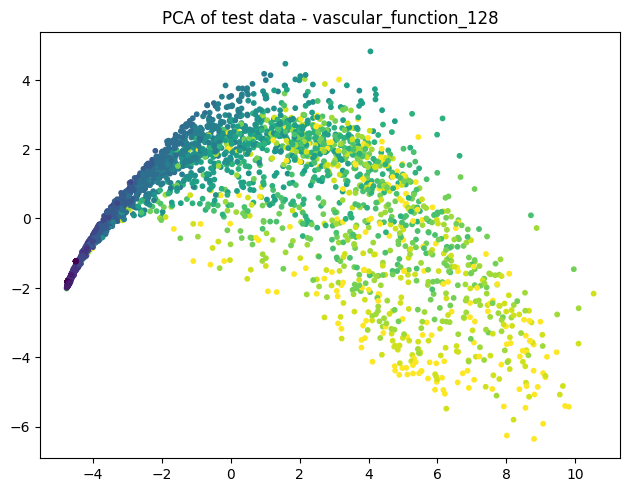

In [129]:
processed_pca = {}

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        if dataset_name in processed_pca:
            continue  

        train_loader = data_loaders[dataset_name]["train"]
        test_loader = data_loaders[dataset_name]["test"]

        def flatten_images(loader):
            flat_images = []
            for batch in loader:
                imgs_batch = batch[0].squeeze()
                flat_imgs = [img.flatten() for img in imgs_batch]
                flat_images.append(np.concatenate(flat_imgs))
            return flat_images

        train_images = flatten_images(train_loader)
        test_images = flatten_images(test_loader)
        test_timepoints = [batch[1].item() for batch in test_loader]

        pca = PCA(n_components=2)
        train_images_pca = pca.fit_transform(train_images)
        test_images_pca = pca.transform(test_images)

        def plot_projection(projection, title):
            plt.scatter(projection[:, 0], projection[:, 1], label="test", c=test_timepoints, s=10)
            plt.tight_layout()
            plt.title(title)
            plt.show()

        plot_projection(test_images_pca, f"PCA of test data - {dataset_name}")

    break

## Visualization of the latent space

In [130]:
timepoints = {}

for model_name, dataset in all_models.items():
    timepoints[model_name] = {}
    for dataset_name, model in dataset.items():
        timepoints[model_name][dataset_name] = []
        loader = data_loaders[dataset_name]["full"]
        for idx in loader._test_indices:
            timepoints[model_name][dataset_name].append(int(loader._get_data_feature(idx, 'timepoint')))

In [131]:
nn_embeddings = {}

for model_name, datasets in all_models.items():
    nn_embeddings[model_name] = {}
    for dataset_name, model in datasets.items():
        nn_embeddings[model_name][dataset_name] = {}
        print(model_name, dataset_name)
            
        test_loader = data_loaders[dataset_name]["test"]
        num_dimensions = model.latent_dim


        model.eval()
        with torch.no_grad():
            encoded_samples = []
            for inputs, _ in test_loader:
                encoded_batch = model.encode(inputs)
                encoded_samples.append(encoded_batch)
            encoded_samples = torch.cat(encoded_samples, dim=0)

        nn_embeddings[model_name][dataset_name] = encoded_samples

cae-medium vascular_function_128
cae-small vascular_function_128


In [132]:
pca_embeddings = {}
for model_name, dataset in nn_embeddings.items():
    pca_embeddings[model_name] = {}
    for dataset_name, embeddings in dataset.items():
        pca = PCA(n_components=2)
        pca_embeddings[model_name][dataset_name] = pca.fit_transform(embeddings)

        print(f"{model_name} | {dataset_name} - Explained Variance: {pca.explained_variance_ratio_}")

cae-medium | vascular_function_128 - Explained Variance: [0.28144439 0.19536954]
cae-small | vascular_function_128 - Explained Variance: [0.26242149 0.18583102]


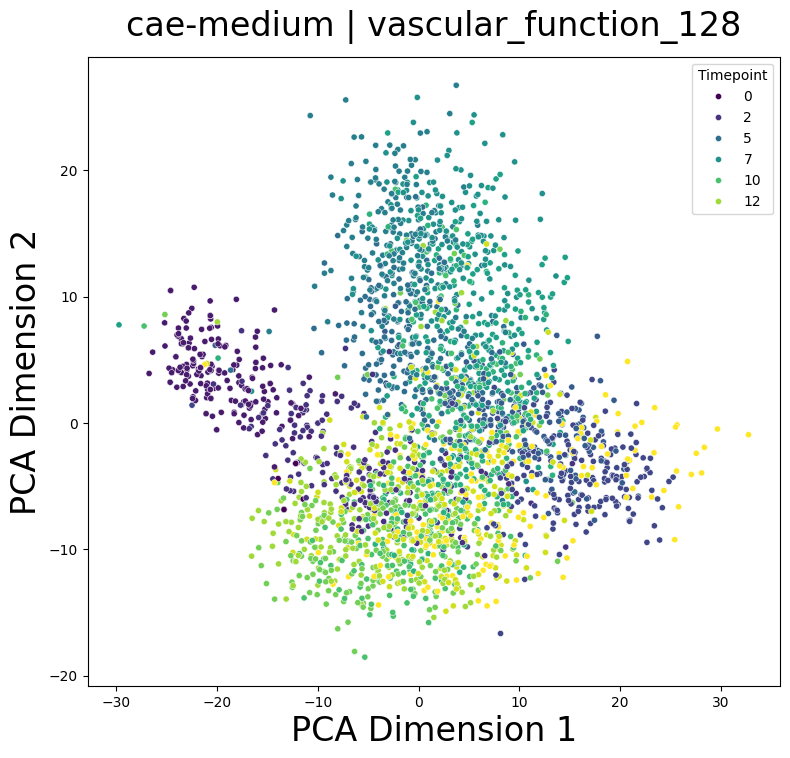

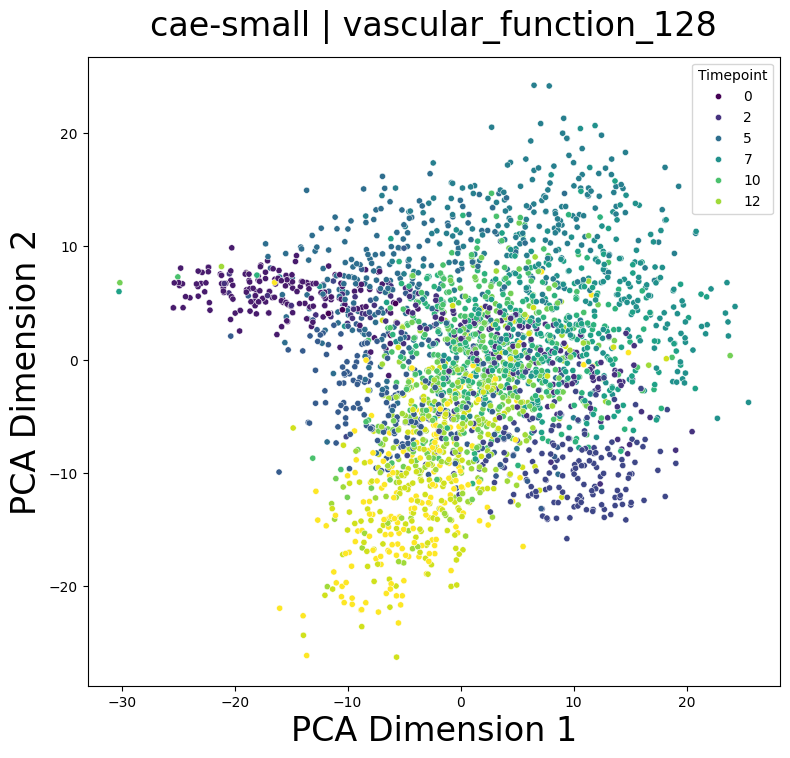

In [133]:
for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        pca_embedding = pca_embeddings[model_name][dataset_name]

        # Convert data into a DataFrame for Seaborn
        df_plot = pd.DataFrame({
            "PCA_1": pca_embedding[:, 0],
            "PCA_2": pca_embedding[:, 1],
            "Timepoint": [int(timepoint) for timepoint in timepoints[model_name][dataset_name]]
        })

        # Create scatter plot
        plt.figure(figsize=(8, 8))
        scatter = sns.scatterplot(
            data=df_plot, x="PCA_1", y="PCA_2", hue="Timepoint", palette="viridis", s=20
        )

        # Customize plot
        plt.title(f'{model_name} | {dataset_name}', fontsize=24, y=1.02)
        plt.xlabel('PCA Dimension 1', fontsize=24)
        plt.ylabel('PCA Dimension 2', fontsize=24)

        # Place the legend inside the plot
        # plt.legend(title="Timepoint", loc="lower right", frameon=True, fontsize=24, fancybox=True)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

In [134]:
processed_pca = {}

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        if dataset_name in processed_pca:
            continue
        else:
            processed_pca[dataset_name] = {}

            train_loader = data_loaders[dataset_name]["train"]
            test_loader = data_loaders[dataset_name]["test"]

            encoder = model.encoder
            last_layer = encoder[-1]
            dim = last_layer.out_features
            
            train_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in train_loader
            ]

            test_images = [
                np.concatenate([img.flatten() for img in batch[0]])
                for batch in test_loader
            ]
        
            pca = PCA(n_components=dim)
            train_pca_images = pca.fit_transform(train_images)
            reconstructed_train_images = pca.inverse_transform(train_pca_images)

            test_pca_images = pca.transform(test_images)
            reconstructed_test_images = pca.inverse_transform(test_pca_images)

            train_mse = mean_squared_error(train_images, reconstructed_train_images)
            test_mse = mean_squared_error(test_images, reconstructed_test_images)

            processed_pca[dataset_name]["train"] = train_mse
            processed_pca[dataset_name]["test"] = test_mse

In [135]:
# nn_reconstructions = {}

# for model_name, dataset in all_models.items():
#     nn_reconstructions[model_name] = {}
#     for dataset_name, model in dataset.items():
#         print(f'{model_name} | {dataset_name}')

#         embeddings = nn_embeddings[model_name][dataset_name]
#         model.eval()
#         with torch.no_grad():
#             reconstructed_samples = model.decode_image(embeddings)
#         reconstructed_samples = reconstructed_samples.reshape(-1, 128 * 128)
        
#         test_loader = data_loaders[dataset_name]["test"]
#         test_images = np.concatenate(
#             [batch[0].numpy().reshape(len(batch[0]), -1) for batch in test_loader],
#             axis=0
#         )
        
#         test_mse = mean_squared_error(test_images, reconstructed_samples)

#         nn_reconstructions[model_name][dataset_name] = test_mse

# print("Reconstruction MSE")
# print(f"{'Model':<15} {'Dataset':<20} {'Test MSE':<15}")
# print("-" * 65)
# for dataset_name, mse in processed_pca.items():
#     print(f"{'PCA':<20} {dataset_name:<20} {mse['test']:<15.6f}")

# for model_name, model_results in nn_reconstructions.items():
#     for dataset_name, mse in model_results.items():
#         print(f"{model_name:<20} {dataset_name:<20} {mse:<15.6f}")

## Latent dimension distributions

Plotting distributions for cae-medium | vascular_function_128


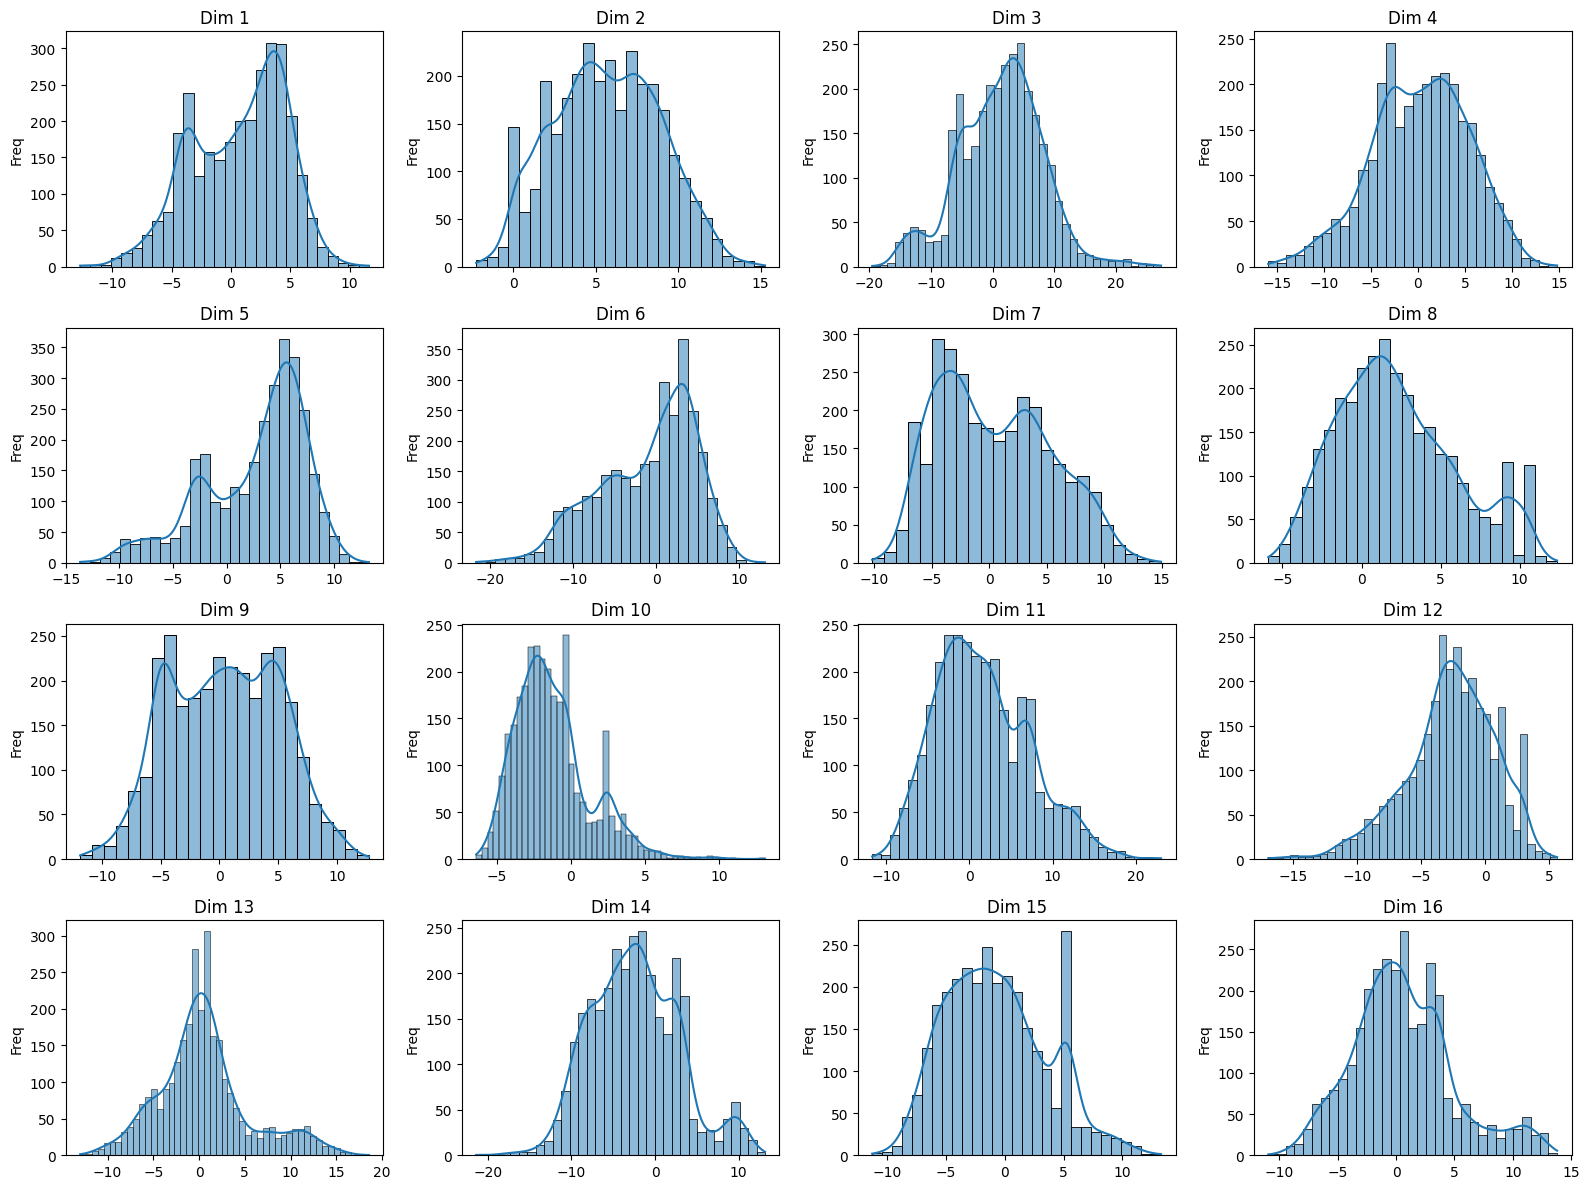

Plotting distributions for cae-small | vascular_function_128


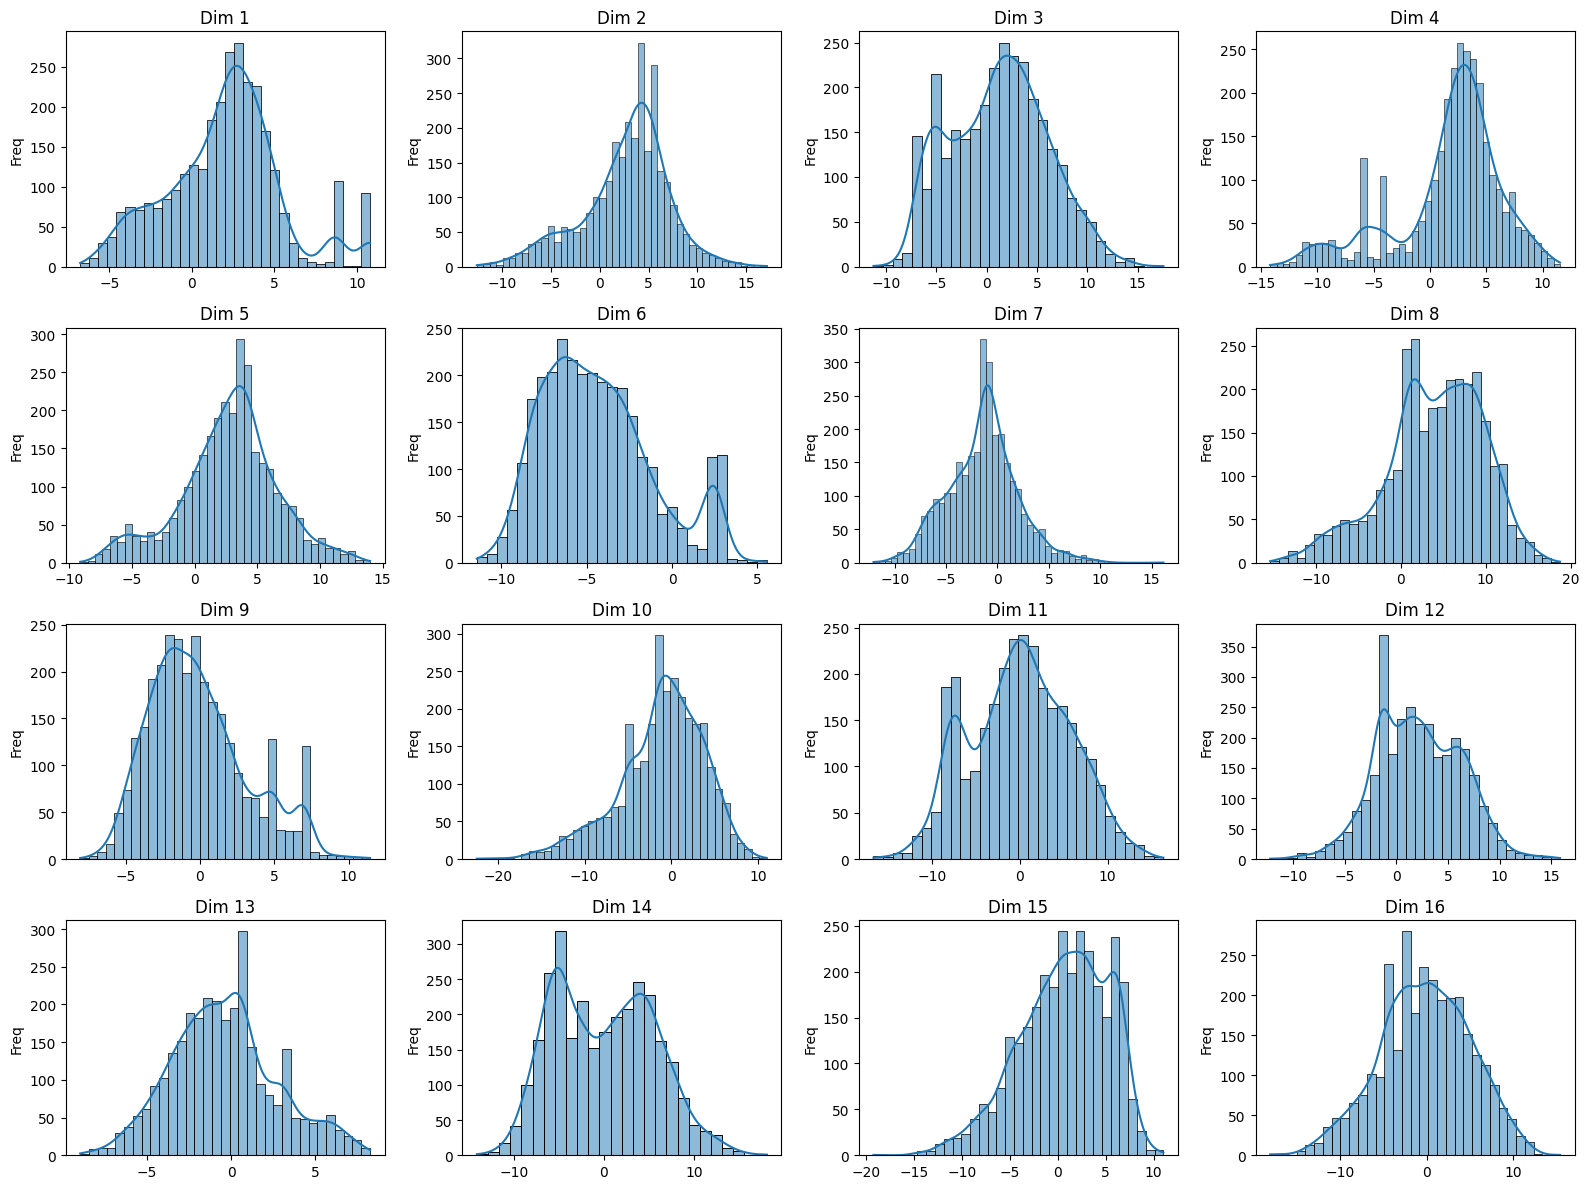

In [136]:
for model_name, dataset in nn_embeddings.items():
    for dataset_name, embeddings in dataset.items():
        num_dimensions = embeddings.shape[1]
            
        if num_dimensions > 32:
            print(f"Skipping {model_name} | {dataset_name} due to large latent space size ({num_dimensions} dimensions)")
            continue

        print(f"Plotting distributions for {model_name} | {dataset_name}")

        cols = 4
        rows = int(np.ceil(num_dimensions / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
        axes = axes.flatten()

        for dim_idx in range(num_dimensions):
            sns.histplot(
                embeddings[:, dim_idx],
                ax=axes[dim_idx],
                kde=True,            
                bins="auto",        
            )
            axes[dim_idx].set_title(f"Dim {dim_idx + 1}")
            axes[dim_idx].set_xlabel("")
            axes[dim_idx].set_ylabel("Freq")

        for ax in axes[num_dimensions:]:
            ax.remove()

        plt.tight_layout()
        plt.show()

In [137]:
# Scan through real image latent space
# for model_name, dataset in all_models.items():
#     for dataset_name, model in dataset.items():
#         embeddings = nn_embeddings[model_name][dataset_name]
#         loader = data_loaders[dataset_name]["full"]
#         num_dimensions = embeddings.shape[1]

#         test_indices = loader._test_indices
#         sample_ids = []
#         dimension_data = [] # List to hold (sample_id, embedding_vector)
#         for idx in test_indices:
#             sample_id = loader._get_data_feature(idx, 'sample_id')
#             sample_ids.append(sample_id)

        # for test_idx in range(len(test_indices)):
        #     full_dataset_idx = test_indices[test_idx]
        #     embedding_vector = embeddings[test_idx]
        #     sample_id = loader._get_data_feature(full_dataset_idx, 'sample_id')
        #     dimension_data.append({'sample_id': sample_id, 'embedding': embedding_vector})

        # for dim_idx in range(num_dimensions):
        #     dimension_values = sorted(dimension_data, key=lambda x: x["embedding"][dim_idx])

        #     min_sample = dimension_values[0]
        #     max_sample = dimension_values[-1]
        #     median_idx = len(dimension_values) // 2
        #     median_sample = dimension_values[median_idx]

        #     fig, axes = plt.subplots(1, 3, figsize=(6,6))
        #     for test_idx in range(len(test_indices)):
            #     full_dataset_idx = test_indices[test_idx]
            #     sample_id = loader._get_data_feature(full_dataset_idx, 'sample_id')
            #     if sample_id == min_sample["sample_id"]:
            #         image, label = data_loaders[dataset_name]["test"].dataset[test_idx]
            #         if label == 14:
            #             axes[0].imshow(image.squeeze(), cmap="gray")
            #             axes[0].axis('off')
            #             axes[0].set_title(f"{sample_id}")
            #     if sample_id == median_sample["sample_id"]:
            #         image, label = data_loaders[dataset_name]["test"].dataset[test_idx]
            #         if label == 14:
            #             axes[1].imshow(image.squeeze(), cmap="gray")
            #             axes[1].axis('off')
            #             axes[1].set_title(f"{sample_id}")
            #     if sample_id == max_sample["sample_id"]:
            #         image, label = data_loaders[dataset_name]["test"].dataset[test_idx]
            #         if label == 14:
            #             axes[2].imshow(image.squeeze(), cmap="gray")
            #             axes[2].axis('off')
            #             axes[2].set_title(f"{sample_id}")

            # plt.tight_layout()
            # plt.show()
        

In [138]:
# for model_name, dataset in nn_embeddings.items():
#     for dataset_name, embeddings in dataset.items():
#         num_dimensions = embeddings.shape[1]
            
#         if num_dimensions >= 32:
#             print(f"Skipping {model_name} | {dataset_name} due to large latent space size ({num_dimensions} dimensions)")
#             continue

#         df = pd.DataFrame(embeddings, columns=[f"Dimension {j+1}" for j in range(num_dimensions)])
#         df["timepoint"] = timepoints[model_name][dataset_name]
        
#         print(f"Plotting for {model_name} | {dataset_name}")
        
#         g = sns.pairplot(df, hue="timepoint", palette="viridis", plot_kws={"s": 15}, corner=True)
#         g._legend.remove()
#         plt.tight_layout()
#         plt.show()

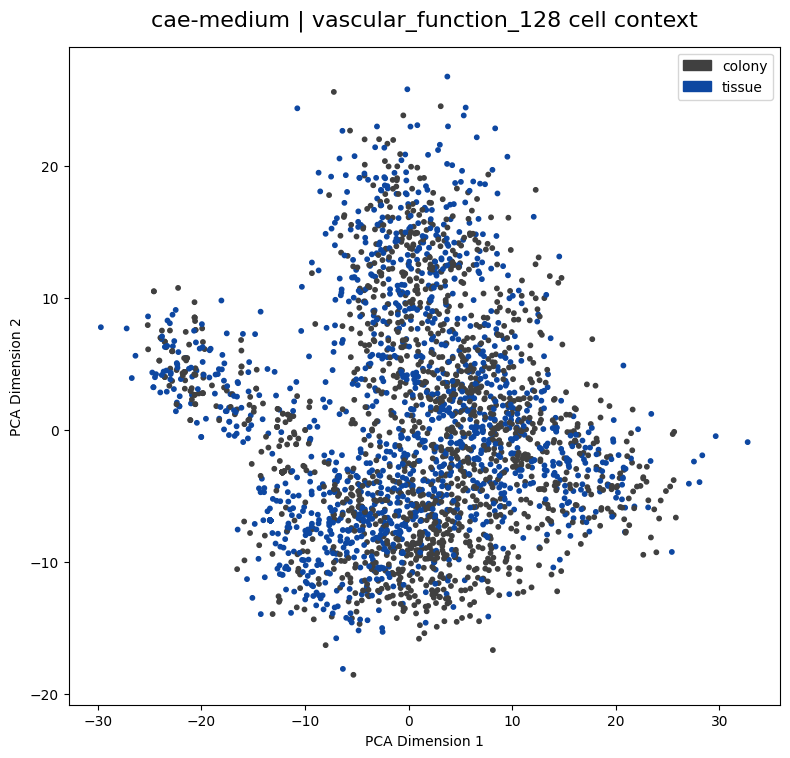

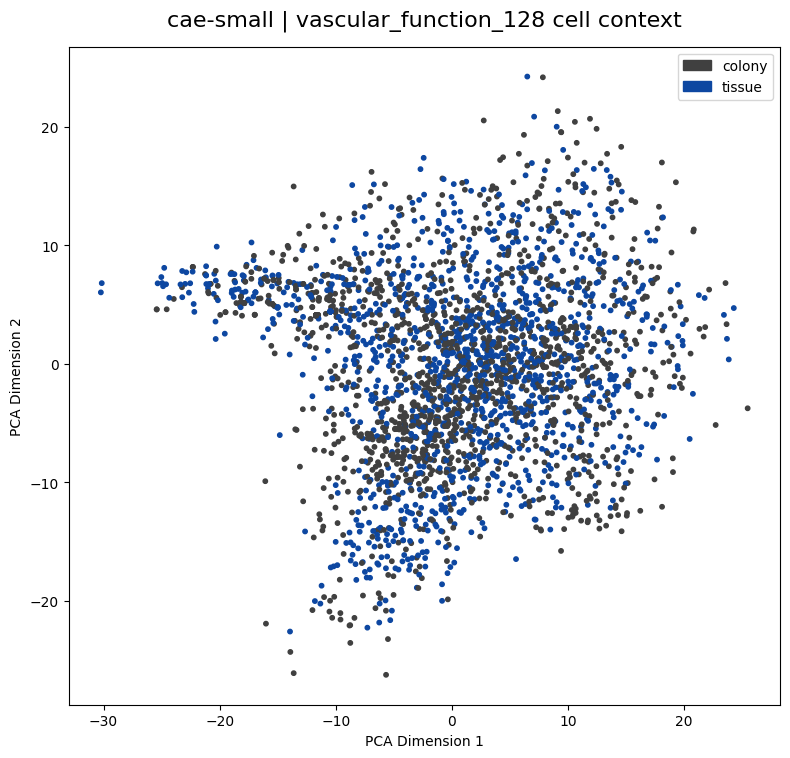

In [139]:
group1 = "C"
group2 = "CH"

cell_context = {}

for model_name, dataset in all_models.items():
    cell_context[model_name] = {}
    for dataset_name, model in dataset.items():
        cell_context[model_name][dataset_name] = []
        loader = data_loaders[dataset_name]["full"]
        for idx in loader._test_indices:
            sample_id = loader._get_data_feature(idx, 'sample_id')
            context = sample_id.split('_')[0]
            
            # context = loader._get_data_feature(idx, 'radiation_type')

            cell_context[model_name][dataset_name].append(context)

base_colors = {group1: "#404040", group2: "#0D47A1"}

for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        pca_embedding = pca_embeddings[model_name][dataset_name]
        contexts = cell_context[model_name][dataset_name]

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(pca_embedding[:, 0], pca_embedding[:, 1], c=[base_colors[context] for context in contexts], s=10)

        ax.set_title(f'{model_name} | {dataset_name} cell context', fontsize=16, y=1.02)
        ax.set_xlabel('PCA Dimension 1')
        ax.set_ylabel('PCA Dimension 2')

        legend_handles = [
            mpatches.Patch(color=base_colors[group1], label='colony'),
            mpatches.Patch(color=base_colors[group2], label='tissue')
        ]
        ax.legend(handles=legend_handles, loc='upper right')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

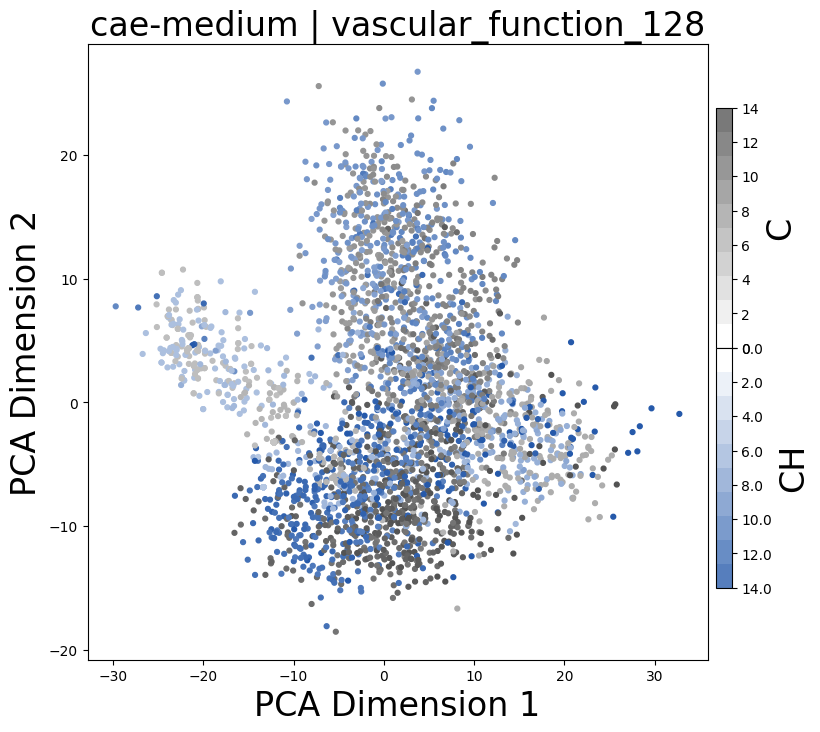

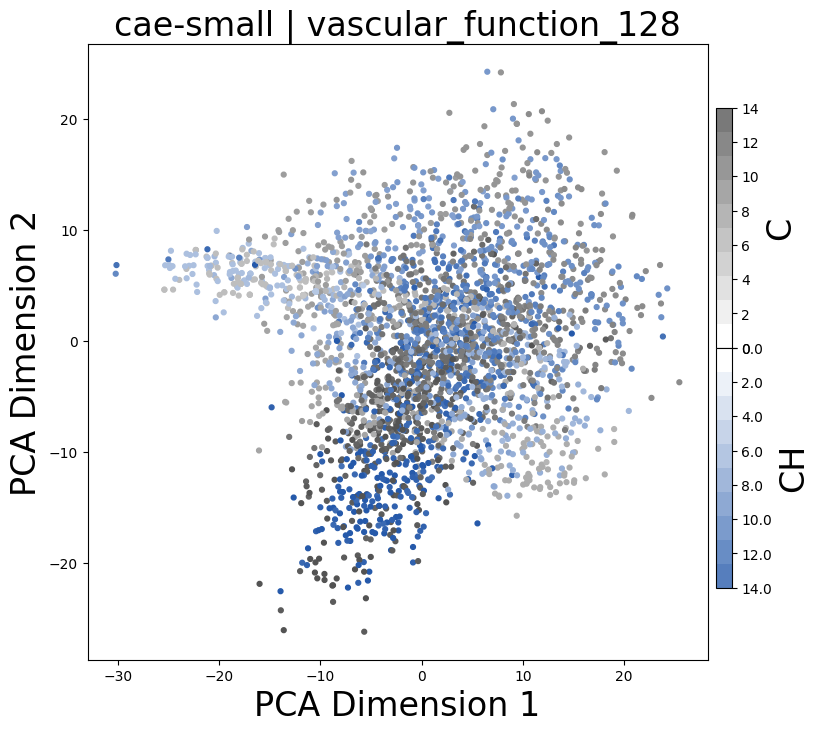

In [140]:
for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        pca_embedding = pca_embeddings[model_name][dataset_name]
        color_array_num = np.array(cell_context[model_name][dataset_name])
        timepoint_vals = np.array(timepoints[model_name][dataset_name])
        
        class1_mask = color_array_num == group1
        class2_mask = color_array_num == group2
        
        fig, ax = plt.subplots(figsize=(8, 8))
        scatter_colors = np.full(len(color_array_num), "#cccccc", dtype=object)  # Default gray
        
        # Process class 1
        if np.any(class1_mask):
            tp_class1 = timepoint_vals[class1_mask]
            tp_norm_class1 = (tp_class1 - tp_class1.min()) / (tp_class1.max() - tp_class1.min()) if tp_class1.max() > tp_class1.min() else np.zeros_like(tp_class1)
            
            # Create color gradient for class 1
            base_color1 = mcolors.to_rgb(base_colors[group1])
            class1_indices = np.where(class1_mask)[0]
            for i, tp_norm in enumerate(tp_norm_class1):
                idx = class1_indices[i]
                lightness = 0.7 - (0.6 * tp_norm)
                adjusted_color = [min(1.0, c + (1-c) * lightness) for c in base_color1]
                scatter_colors[idx] = mcolors.to_hex(adjusted_color)
        
        # Process class 2
        if np.any(class2_mask):
            tp_class2 = timepoint_vals[class2_mask]
            tp_norm_class2 = (tp_class2 - tp_class2.min()) / (tp_class2.max() - tp_class2.min()) if tp_class2.max() > tp_class2.min() else np.zeros_like(tp_class2)
            
            # Create color gradient for class 2
            base_color2 = mcolors.to_rgb(base_colors[group2])
            class2_indices = np.where(class2_mask)[0]
            for i, tp_norm in enumerate(tp_norm_class2):
                idx = class2_indices[i]
                lightness = 0.7 - (0.6 * tp_norm)
                adjusted_color = [min(1.0, c + (1-c) * lightness) for c in base_color2]         
                scatter_colors[idx] = mcolors.to_hex(adjusted_color)
        
        # Check for any None values and replace them
        for i in range(len(scatter_colors)):
            if scatter_colors[i] is None:
                print(f"Warning: Found None color at index {i}")
                scatter_colors[i] = "#cccccc"  # Default to gray
        
        sp = ax.scatter(pca_embedding[:, 0], pca_embedding[:, 1], c=scatter_colors, s=12)
    
        class1_colors = [mcolors.to_rgb([min(1.0, c + (1-c) * (1.0 - t)) for c in mcolors.to_rgb(base_colors[group1])]) for t in np.linspace(0, 0.7, 10)]
        class2_colors = [mcolors.to_rgb([min(1.0, c + (1-c) * (1.0 - t)) for c in mcolors.to_rgb(base_colors[group2])]) for t in np.linspace(0, 0.7, 10)]
        class2_colors = class2_colors[::-1]
        
        cmap1 = ListedColormap(class1_colors)
        cmap2 = ListedColormap(class2_colors)
        
        ax1 = fig.add_axes([0.91, 0.5, 0.02, 0.3])
        ax2 = fig.add_axes([0.91, 0.2, 0.02, 0.3])
        
        sm1 = plt.cm.ScalarMappable(cmap=cmap1, norm=plt.Normalize(vmin=min(timepoint_vals), vmax=max(timepoint_vals)))
        sm1.set_array([])
        cbar1 = plt.colorbar(sm1, cax=ax1)
        cbar1.set_label(group1, fontsize=24, labelpad=4)
        
        sm2 = plt.cm.ScalarMappable(cmap=cmap2, norm=plt.Normalize(vmin=min(timepoint_vals), vmax=max(timepoint_vals)))
        sm2.set_array([])
        cbar2 = plt.colorbar(sm2, cax=ax2)
        ticks = cbar2.get_ticks()
        cbar2.set_ticks(ticks)
        cbar2.set_ticklabels([f"{tick:.1f}" for tick in reversed(ticks)])
        cbar2.set_label(group2, fontsize=24, labelpad=4)
        
        
        ax.set_title(f"{model_name} | {dataset_name}", fontsize=24)
        ax.set_xlabel('PCA Dimension 1', fontsize=24)
        ax.set_ylabel('PCA Dimension 2', fontsize=24)
        
        plt.show()

In [141]:
classification_file = f"results_downstream/{study_name}_classification_results.json"
incorrect_samples = defaultdict(lambda: defaultdict(list))

try:
    with open(classification_file, "r") as f:
        classification_results = json.load(f)
        

    for item in classification_results["model_dataset_results"]:
        model_name = item["model_name"]
        dataset_name = item["dataset_name"]
        incorrect_samples[model_name][dataset_name] = item["incorrect_predictions"]
        

    for model_name, datasets in all_models.items():
        for dataset_name, model in datasets.items():
            
            pca_embedding = pca_embeddings[model_name][dataset_name]
            current_sample_ids = sample_ids[model_name][dataset_name]
            current_timepoints = timepoints[model_name][dataset_name]
            incorrect = incorrect_samples[model_name][dataset_name]

            min_timepoint = min(current_timepoints)
            max_timepoint = max(current_timepoints)

            pca_embedding_array1 = []
            point_colors_array1 = []
            trajectory_data_array1 = defaultdict(list)

            pca_embedding_array2 = []
            point_colors_array2 = []
            trajectory_data_array2 = defaultdict(list)

            for i in range(len(pca_embedding)):
                sid = current_sample_ids[i]
                tp = current_timepoints[i]
                embedding = pca_embedding[i, :]

                base_hex = None
                array_type = None

                if sid.startswith('array1'):
                    base_hex = base_colors[1]
                    array_type = 1
                elif sid.startswith('array2'):
                    base_hex = base_colors[2]
                    array_type = 2

                if base_hex:
                    shaded_color_rgb = get_shaded_color(base_hex, tp, min_timepoint, max_timepoint)

                    if array_type == 1:
                        pca_embedding_array1.append(embedding)
                        point_colors_array1.append(shaded_color_rgb)
                        trajectory_data_array1[sid].append((tp, embedding, shaded_color_rgb))
                    elif array_type == 2:
                        pca_embedding_array2.append(embedding)
                        point_colors_array2.append(shaded_color_rgb)
                        trajectory_data_array2[sid].append((tp, embedding, shaded_color_rgb))


            pca_embedding_array1 = np.array(pca_embedding_array1)
            pca_embedding_array2 = np.array(pca_embedding_array2)

            fig1, ax1 = plt.subplots(figsize=(8, 8))

            sns.scatterplot(x=pca_embedding_array1[:, 0], y=pca_embedding_array1[:, 1],
                            ax=ax1,
                            c=point_colors_array1,
                            s=15, edgecolor='none', alpha=0.6)

            for sid, trajectory_list in trajectory_data_array1.items():
                is_incorrect = sid in incorrect
                trajectory_list.sort(key=lambda x: x[0])

                for j in range(len(trajectory_list) - 1):
                    start_tp, start_embedding, start_color = trajectory_list[j]
                    end_tp, end_embedding, end_color = trajectory_list[j+1]

                    line_color = 'red' if is_incorrect else start_color
                    line_style = '-' if is_incorrect else '--'
                    line_width = 0.7 if is_incorrect else 2.0
                    line_alpha = 0.8 if is_incorrect else 0.4

                    ax1.plot([start_embedding[0], end_embedding[0]],
                            [start_embedding[1], end_embedding[1]],
                            color=line_color,
                            linestyle=line_style,
                            linewidth=line_width,
                            alpha=line_alpha)

            ax1.grid(False)
            ax1.set_title(f'{model_name} | {dataset_name} - Euploid', fontsize=16, y=1.02)
            ax1.set_xlabel('PCA Dimension 1')
            ax1.set_ylabel('PCA Dimension 2')

            legend_handles = [mpatches.Patch(color=base_colors[1], label='Euploid')]
            if any(sid in incorrect_samples for sid in trajectory_data_array1):
                legend_handles.append(mpatches.Patch(color='red', label='Incorrectly Classified Trajectory'))

            ax1.legend(handles=legend_handles, loc='upper right')

            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()

            fig2, ax2 = plt.subplots(figsize=(8, 8))

            sns.scatterplot(x=pca_embedding_array2[:, 0], y=pca_embedding_array2[:, 1],
                            ax=ax2,
                            c=point_colors_array2,
                            s=15, edgecolor='none', alpha=0.6)

            for sid, trajectory_list in trajectory_data_array2.items():
                is_incorrect = sid in incorrect
                trajectory_list.sort(key=lambda x: x[0])

                for j in range(len(trajectory_list) - 1):
                    start_tp, start_embedding, start_color = trajectory_list[j]
                    end_tp, end_embedding, end_color = trajectory_list[j+1]

                    line_color = 'red' if is_incorrect else start_color
                    line_style = '-' if is_incorrect else '--'
                    line_width = 0.7 if is_incorrect else 2.0
                    line_alpha = 0.8 if is_incorrect else 0.4

                    ax2.plot([start_embedding[0], end_embedding[0]],
                            [start_embedding[1], end_embedding[1]],
                            color=line_color,
                            linestyle=line_style,
                            linewidth=line_width,
                            alpha=line_alpha)


            ax2.grid(False)
            ax2.set_title(f'{model_name} | {dataset_name} - Aneuploid', fontsize=16, y=1.02)
            ax2.set_xlabel('PCA Dimension 1')
            ax2.set_ylabel('PCA Dimension 2')

            legend_handles = [mpatches.Patch(color=base_colors[2], label='Aneuploid')]
            if any(sid in incorrect for sid in trajectory_data_array2):
                legend_handles.append(mpatches.Patch(color='red', label='Incorrectly Classified Trajectory'))

            ax2.legend(handles=legend_handles, loc='upper right')

            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()

except:
    pass

C_Lvav_55


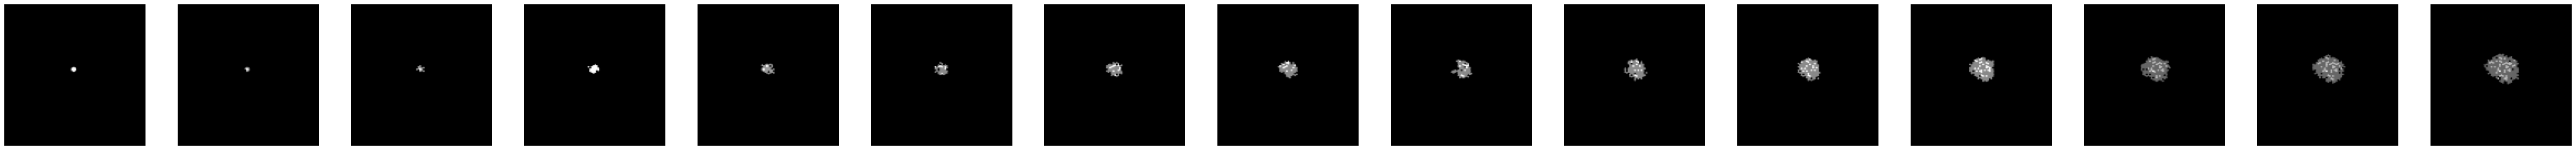

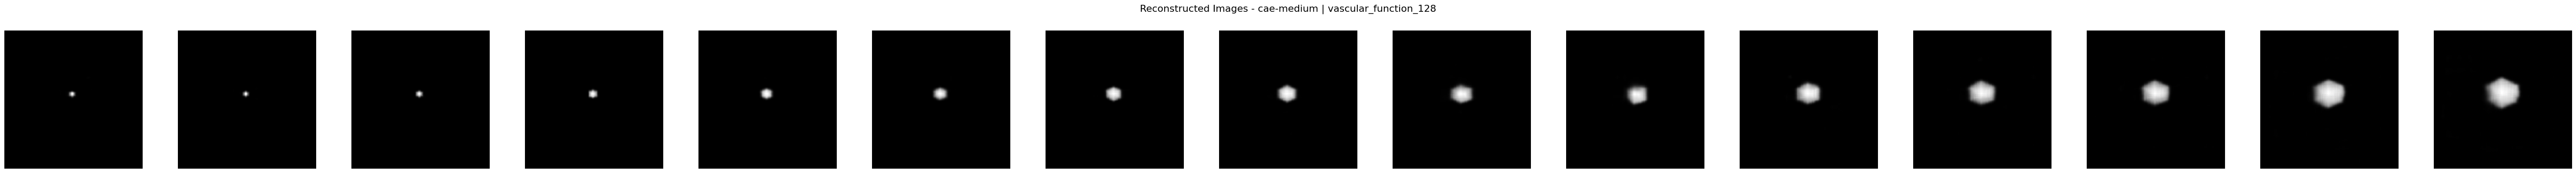

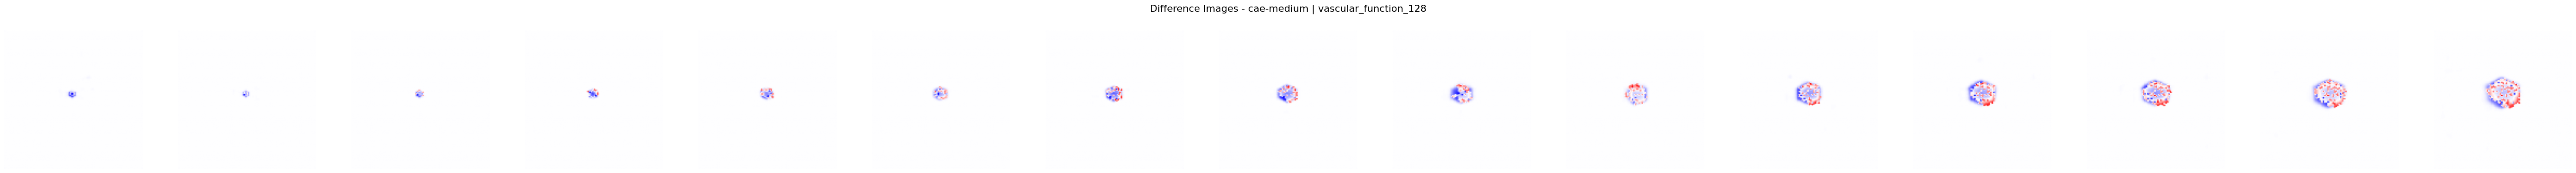

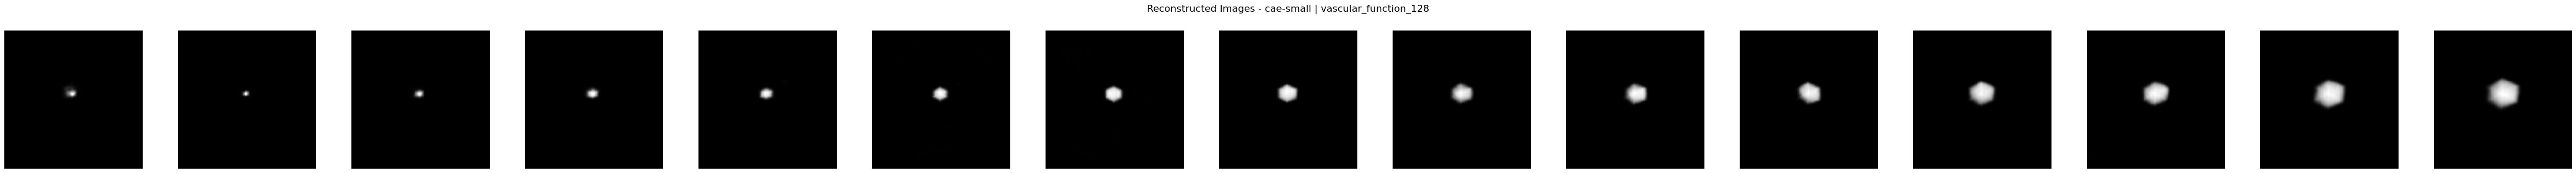

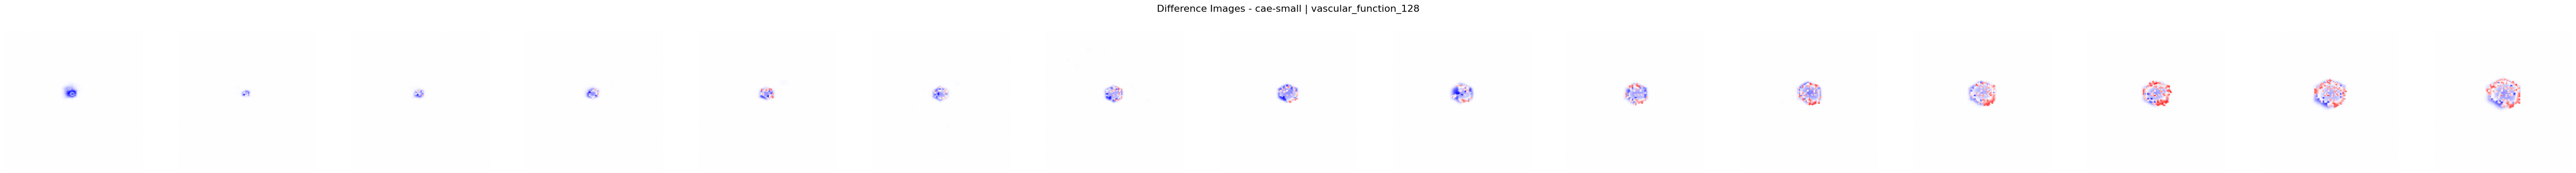

In [142]:
target_sample = "CH_Sav_8"
condition = "tissue" if "CH" in target_sample else "colony"

dataset_name = list(all_loaders.keys())[0]
loader = data_loaders[dataset_name]["full"]
matching_samples = []

for idx in loader._test_indices:
    sample_id = loader._get_data_feature(idx, 'sample_id')
    if sample_id == target_sample:
        timepoint = int(loader._get_data_feature(idx, 'timepoint'))
        matching_samples.append({'idx': idx, 'timepoint': timepoint, 'sample_id': sample_id})

sorted_samples = sorted(matching_samples, key=lambda x: x['timepoint'])
sorted_indices = [s['idx'] for s in sorted_samples]
sorted_timepoints = [s['timepoint'] for s in sorted_samples]

images = []
for idx in sorted_indices:
    image_group = loader.data[idx]
    image_path = image_group["cancer"]
    img = plt.imread(image_path)[:, :, 0]
    images.append(img)

num_images = len(images)

if num_images > 0:
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))

    print(f"{sample_id}")

    for i, (img, timepoint) in enumerate(zip(images, sorted_timepoints)):
        plt.imsave(f"figures/{sample_id}_{i}.png", img, cmap='gray')
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()


for model_name, datasets in all_models.items():
    for dataset_name, model in datasets.items():
        recon_images_current_model = []
        for img in images:
            img_tensor = torch.Tensor(img).unsqueeze(0).unsqueeze(0)
            reconstructed_img, _ = model(img_tensor)
            recon_images_current_model.append(reconstructed_img)

        # Plot reconstructed images
        num_recon_to_plot = len(recon_images_current_model)
        fig, axes = plt.subplots(1, num_recon_to_plot, figsize=(4 * num_recon_to_plot, 4))
        for i, recon_img_tensor in enumerate(recon_images_current_model):
            recon_img = recon_img_tensor.squeeze().detach().numpy()
            plt.imsave(f"figures/{study_name}_reconstructed_{sample_id}_{model_name}_{dataset_name}_{i}.png",
                       recon_img, cmap='gray')
            axes[i].imshow(recon_img, cmap='gray')
            axes[i].axis('off')
        fig.suptitle(f'Reconstructed Images - {model_name} | {dataset_name}', fontsize=16, y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96]) 
        plt.show()

        # Plot and save pixel-wise difference images
        fig, axes = plt.subplots(1, num_recon_to_plot, figsize=(4 * num_recon_to_plot, 4))
        for i, (orig_img, recon_img_tensor) in enumerate(zip(images, recon_images_current_model)):
            recon_img = recon_img_tensor.squeeze().detach().numpy()

            orig_img_norm = orig_img.astype(np.float32)
            if orig_img_norm.max() > 1.0:
                orig_img_norm /= 255.0

            diff = orig_img_norm - recon_img
            vmax = np.max(np.abs(diff)) 

            diff_path = f"figures/{study_name}_diff_{sample_id}_{model_name}_{dataset_name}_{i}.png"
            plt.imsave(diff_path, diff, cmap='bwr', vmin=-vmax, vmax=vmax)

            axes[i].imshow(diff, cmap='bwr', vmin=-vmax, vmax=vmax)
            axes[i].axis('off')

        fig.suptitle(f'Difference Images - {model_name} | {dataset_name}', fontsize=16, y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()